## Suit test for Installation of the Dataset

In [44]:
import os
import sys
import numpy as np
import matplotlib.pylab as plt

In [18]:
cwd = os.getcwd()
root = "/".join(cwd.split("/")[:-1])
libs_path = os.path.join(root, "bigearthnet/explore")
print(f"cwd: {cwd}","\n",f"root: {root}","\n", f"libs_path: {libs_path}")

## append to make it the modules available
sys.path.append(libs_path)

cwd: /root/bigearthnet/BigEarthNet-Models/notebooks 
 root: /root/bigearthnet/BigEarthNet-Models 
 libs_path: /root/bigearthnet/BigEarthNet-Models/bigearthnet/explore


In [20]:
## Import 
from src.loader.reader import Dataset_BigEarthNet, Reader

In [ ]:
## Reader Module. It reads to file-tree structure of the BigEarthNet
reader = Reader(
    root_folder_path="~/storage_ds/BigEarthNet-S2",
    metadata_parquet_path ="/root/bigearthnet/BigEarthNet-Models/df_balanced/teste2.parquet"
)

2025-08-28 08:54:44.920 | INFO     | src.loader.reader:__init__:170 - Initializing the Reader, structuring the paths and files.
2025-08-28 08:54:45.111 | INFO     | src.loader.reader:parent_folders:224 - Found 115 folders in /root/storage_ds/BigEarthNet-S2
2025-08-28 08:54:50.992 | INFO     | src.loader.reader:_create_lookup_structures:208 - Created lookup structures for 145781 patches
2025-08-28 08:54:51.005 | INFO     | src.loader.reader:__init__:192 - None


Number of parent folders: 115
Number of total patches found it: 549488


In [27]:
## Check the metadata 
reader.metadata_parquet.head()

,patch_id,labels,split,country,s1_name,s2v1_name,contains_seasonal_snow,contains_cloud_or_shadow
110560,S2A_MSIL2A_20171121T112351_N9999_R037_T29SND_7...,"[Agro-forestry areas, Transitional woodland, s...",train,Portugal,S1A_IW_GRDH_1SDV_20171122T063450_29SND_72_79,S2A_MSIL2A_20171121T112351_72_79,False,False
87781,S2A_MSIL2A_20171002T112111_N9999_R037_T29SNC_6...,[Agro-forestry areas],train,Portugal,S1A_IW_GRDH_1SDV_20171005T063451_29SNC_66_1,S2A_MSIL2A_20171002T112111_66_1,False,False
359975,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_4...,"[Agro-forestry areas, Pastures, Permanent crop...",test,Portugal,S1B_IW_GRDH_1SDV_20180225T064227_29SNC_42_27,S2B_MSIL2A_20180224T112109_42_27,False,False
361640,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_6...,"[Agro-forestry areas, Arable land, Mixed fores...",test,Portugal,S1A_IW_GRDH_1SDV_20180225T183447_29SNC_60_58,S2B_MSIL2A_20180224T112109_60_58,False,False
362059,S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_6...,"[Agro-forestry areas, Complex cultivation patt...",test,Portugal,S1A_IW_GRDH_1SDV_20180225T183512_29SNC_65_23,S2B_MSIL2A_20180224T112109_65_23,False,False


In [ ]:
## Check a patch
reader.__getitem__(reader.metadata_parquet["patch_id"].iloc[0])

({'B11': array([[4228, 4496, 3793, ..., 3790, 3371, 3830],
         [3365, 3715, 3765, ..., 3813, 3539, 3977],
         [2992, 3143, 3490, ..., 3671, 3436, 3687],
         ...,
         [2230, 1820, 1691, ..., 2809, 3471, 3831],
         [1849, 1592, 1544, ..., 2621, 3217, 3671],
         [1708, 1702, 1740, ..., 1937, 2034, 2721]], dtype=uint16),
  'B12': array([[3254, 3433, 2689, ..., 2728, 2273, 2745],
         [2408, 2778, 2627, ..., 2761, 2455, 2845],
         [2091, 2199, 2508, ..., 2705, 2402, 2640],
         ...,
         [1400, 1132, 1060, ..., 1851, 2435, 2663],
         [1229,  973,  960, ..., 1776, 2207, 2554],
         [1093, 1006, 1097, ..., 1283, 1474, 1875]], dtype=uint16),
  'B05': array([[1660, 1782, 1405, ..., 1213, 1080, 1481],
         [1269, 1454, 1513, ..., 1322, 1235, 1462],
         [1056, 1131, 1391, ..., 1350, 1206, 1282],
         ...,
         [ 806,  652,  564, ..., 1030, 1378, 1551],
         [ 719,  541,  547, ...,  983, 1346, 1540],
         [ 606,  586,

In [ ]:
## Looking into the patch
img, lbl = reader.__getitem__(reader.metadata_parquet["patch_id"].iloc[0])
print(f" Image type: {type(img)}")
print(f" Shape Image band B2: {img['B02'].shape}")
print(f" Shape Image band B3: {img['B03'].shape}")
print(f" Shape Image band B4: {img['B04'].shape}") ## 10m resolution
print(f" Shape Image band B6: {img['B06'].shape}") ## 20m resolution
print(f" Shape Image band B6: {img['B01'].shape}") ## 60m resolution
print(f"Labels: {lbl}")

 Image type: <class 'dict'>
 Shape Image band B2: (120, 120)
 Shape Image band B3: (120, 120)
 Shape Image band B4: (120, 120)
 Shape Image band B6: (60, 60)
 Shape Image band B6: (20, 20)
Labels: ['Agro-forestry areas' 'Transitional woodland, shrub']


Text(0.5, 1.0, "['Agro-forestry areas' 'Transitional woodland, shrub']")

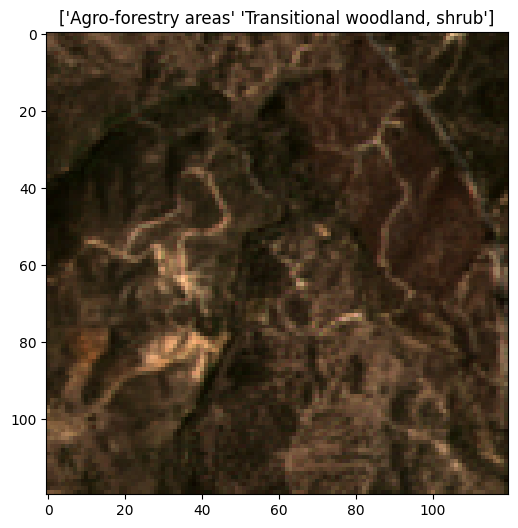

In [60]:
## Plot the image
rgb = np.stack([img["B04"], img["B03"], img["B02"]])
norm = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb))
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(norm, (2,1,0)))
plt.title(lbl)

Text(0.5, 0.98, 'BigEarthNet Dataset')

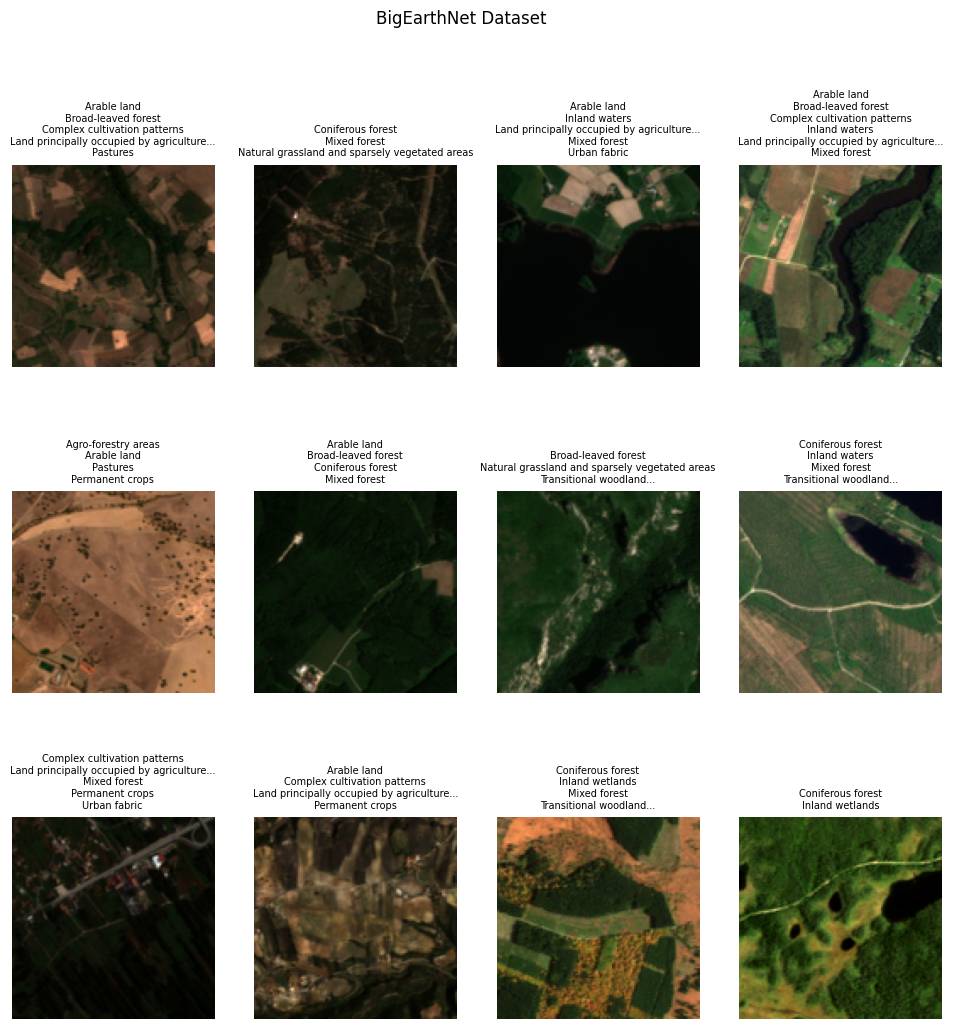

In [130]:
from random import randint
list_tiles_names = reader.metadata_parquet['patch_id'].sample(12)

dict_img = {}
for patch in list_tiles_names:
    img, lbl = reader.__getitem__(patch)
    rgb = np.stack([img["B04"], img["B03"], img["B02"]])
    norm = (rgb - np.min(rgb)) / (np.max(rgb) - np.min(rgb))
    dict_img[patch] = (norm, lbl) 

## plot 
rows = 3
cols = 4
fig, axes = plt.subplots(nrows=rows,ncols=cols,figsize= (12,12))
## CREATE THE LOOP FOR PLOT 
for idx, (img, lbl) in enumerate(dict_img.values()):
    row = idx // cols
    col = idx % cols
    ## W,H,C
    imgm = np.transpose(img, (2,1,0))

    axes[row,col].imshow(imgm)

    ## Fix it the labels title 
    ## if label is to big, split at the comma
    lbl_ = [ f"{label.split(',')[0]}..." if len(label.split(','))>1 else label.split(',')[0] for label in lbl]
    title = f"{'\n'.join(lbl_)}"
    axes[row,col].set_title(title, fontsize='7')
    axes[row,col].axis('off')
fig.suptitle('BigEarthNet Dataset',size='12')

In [129]:
randint(12)

TypeError: Random.randint() missing 1 required positional argument: 'b'